# Eigenmode Bases

This tutorial demonstrates how to use the eigenmode basis functionality in SpectraNorm. Eigenmode bases are a powerful tool for representing and analyzing high-dimensional data in a lower-dimensional latent space.

## Overview

In this tutorial, we will cover the following topics:

1. What are eigenmode bases?
2. How to compute eigenmode bases using SpectraNorm.
3. How to use eigenmode bases for data analysis.

## What are Eigenmode Bases?

Eigenmode bases are a set of (usually orthonormal) basis functions that can be used to represent high-dimensional data in a lower-dimensional latent space. They can be derived from the eigenvectors of a Laplacian matrix describing the data structure.

Here, we'll focus on graph theoretical approaches to compute eigenmode bases, which are particularly useful for analyzing high-dimensional data that is expressed over a graph-like structure (e.g., social networks, brain connectivity, transportation networks, etc.).

### A simple lattice example

To illustrate the concept of eigenmode bases, let's consider a simple 2D lattice graph. This is a simple grid structure that can be used to represent spatial data confined to a 2D plane.

In the script below, we will create a 50x50 lattice graph to be used for the rest of the tutorial.



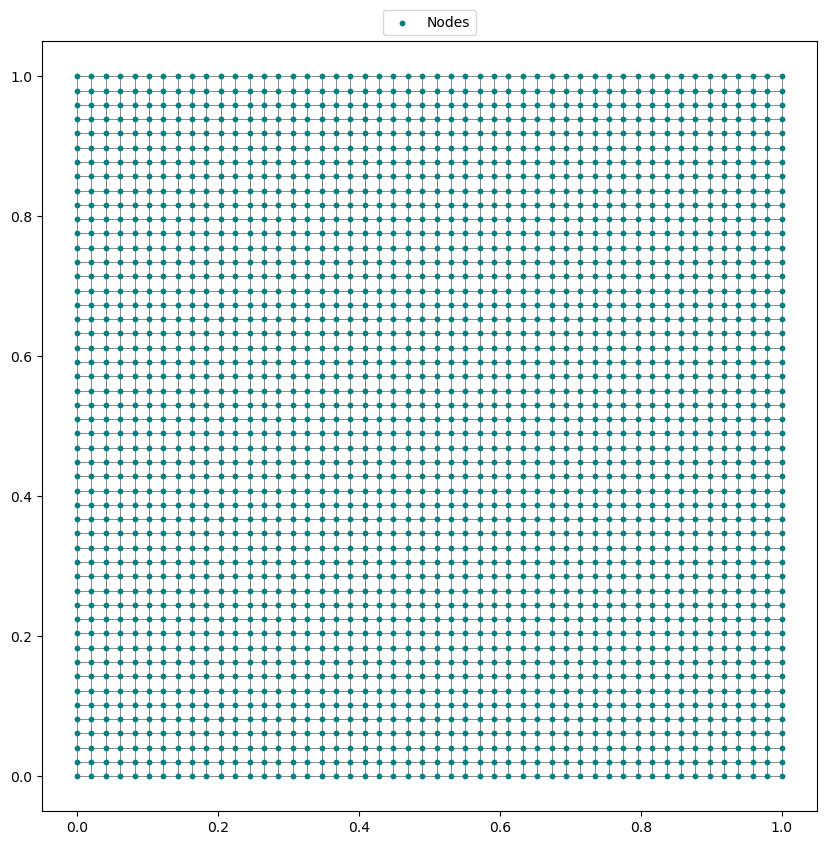

In [1]:
"""
We want to create a 50x50 lattice structure, containing 2,500 nodes, together
representing a 2D spatial domain covering points from (0, 0) to (1, 1). Each node in
this lattice will be associated with a specific point in this spatial domain. The
lattice will be constructed such that the nodes are evenly spaced.

To achieve this, we will define a grid of points where each point corresponds to a node
in the lattice. The spacing between the nodes will be determined by dividing the range
of the spatial domain (which is 1 unit in both x and y directions) by the number of
nodes along each dimension (which is 50). This means that each node will be spaced
0.02 units apart in both directions.

Assuming every node is connected to its immediate neighbors (up, down, left, right), we
can represent the connections between the nodes using a sparse adjacency matrix. This
matrix will have dimensions of 2,500 x 2,500, where each entry indicates whether there
is a connection between the corresponding nodes. The connections will be represented as
1s in the matrix, while the absence of connections will be represented as 0s. This
sparse representation is efficient for large matrices where most entries are zero, which
is the case here since each node is only connected to a few neighbors.
"""

# Several imports used in this notebook
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse

# Import the SpectraNorm package
from spectranorm import snm

# Define the number of nodes along each dimension
num_nodes = 50

# Create a grid of points
x = np.linspace(0, 1, num_nodes)
y = np.linspace(0, 1, num_nodes)
X, Y = np.meshgrid(x, y)

# Flatten the grid to create a list of node coordinates
nodes = np.column_stack((X.flatten(), Y.flatten()))

# Let's create a sparse adjacency matrix to represent the connections between the nodes
adjacency_matrix = sparse.lil_matrix((num_nodes**2, num_nodes**2))

# Connect each node to its immediate neighbors (up, down, left, right)
for i in range(num_nodes):
    for j in range(num_nodes):
        node_index = i * num_nodes + j
        if i > 0:  # Connect to the node above
            adjacency_matrix[node_index, (i - 1) * num_nodes + j] = 1
        if i < num_nodes - 1:  # Connect to the node below
            adjacency_matrix[node_index, (i + 1) * num_nodes + j] = 1
        if j > 0:  # Connect to the node to the left
            adjacency_matrix[node_index, i * num_nodes + (j - 1)] = 1
        if j < num_nodes - 1:  # Connect to the node to the right
            adjacency_matrix[node_index, i * num_nodes + (j + 1)] = 1

# Let's convert the adjacency matrix to a more efficient format for computations
adjacency_matrix = adjacency_matrix.tocsr()

# Plot the lattice structure and the connections between the nodes
plt.figure(figsize=(10, 10))

# Plot the nodes
plt.scatter(nodes[:, 0], nodes[:, 1], color="teal", s=10, label="Nodes", zorder=2)

# Plot the connections
for i in range(num_nodes**2):
    neighbors = adjacency_matrix[i].nonzero()[1]
    for neighbor in neighbors:
        plt.plot(
            [nodes[i, 0],
             nodes[neighbor, 0]],
             [nodes[i, 1], nodes[neighbor, 1]],
             color="gray", linewidth=0.5, zorder=1,
        )

# Legend outside the axis
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05))
plt.show()

As evident in the plot, the lattice graph consists of nodes arranged in a grid pattern, with edges connecting neighboring nodes. This structure can be used to encode high-dimensional data that has a spatial organization, such as images or information confined to a 2D plane.

Theories in graph signal processing allow us to compute eigenmode bases from a given graph structure, which can then be used to represent and analyze data defined over that graph. In the next section, we will see how to compute eigenmode bases using `SpectraNorm`.

## Computing Eigenmode Bases

We can use the [Graph Signal Processing (GSP) utilities](/spectranorm/api/utils/gsp/) in SpectraNorm to compute eigenmode bases from a given graph, e.g., the lattice graph we just created. The GSP module provides functions to compute the graph Laplacian and its eigenvectors, which form the eigenmode basis.

Considering that our lattice graph has 2500 nodes, the complete set of eigenmodes would consist of 2500 eigenvectors. However, in practice, we often only need a subset of these eigenmodes to capture the essential structure of the data. For example, as shown in the script below, we might choose to compute only the first 100 eigenmodes, which correspond to the lowest frequencies in the graph.

In [2]:
# Let's first compute the eigenvalues and eigenvectors of the graph Laplacian
(
    eigenvalues, eigenvectors
) = snm.utils.gsp.compute_symmetric_normalized_laplacian_eigenmodes(
    adjacency_matrix=adjacency_matrix,
    num_eigenvalues=100,
)

# Now let's store the outputs in an `EigenmodeBasis` object
eigenmode_basis = snm.utils.gsp.EigenmodeBasis(
    eigenvalues=eigenvalues[:100],
    eigenvectors=eigenvectors.T[:, :100],
)

eigenmode_basis

EigenmodeBasis(n_modes=100, n_features=2500)

Note that the [`gsp.EigenmodeBasis`](/spectranorm/api/utils/gsp/#spectranorm.utils.gsp.EigenmodeBasis) class in SpectraNorm provides a convenient interface for working with eigenmode bases. As we will see in the coming sections, this class allows us to easily encode and decode data using the computed eigenmode basis.

But before we dive into encoding and decoding, let's first visualize some of the computed eigenmodes to get an intuition for what they represent. The first few eigenmodes typically capture the low-frequency components of the graph, which correspond to smooth variations across the network. As we move to higher eigenmodes, we capture higher-frequency components, which correspond to more localized variations in the data.

The following visualization, benefits from the fact that our lattice graph has a spatial structure, allowing us to plot the eigenmodes as images. Each eigenmode can be reshaped back into a 50x50 grid, revealing patterns that correspond to different spatial frequencies on the lattice.

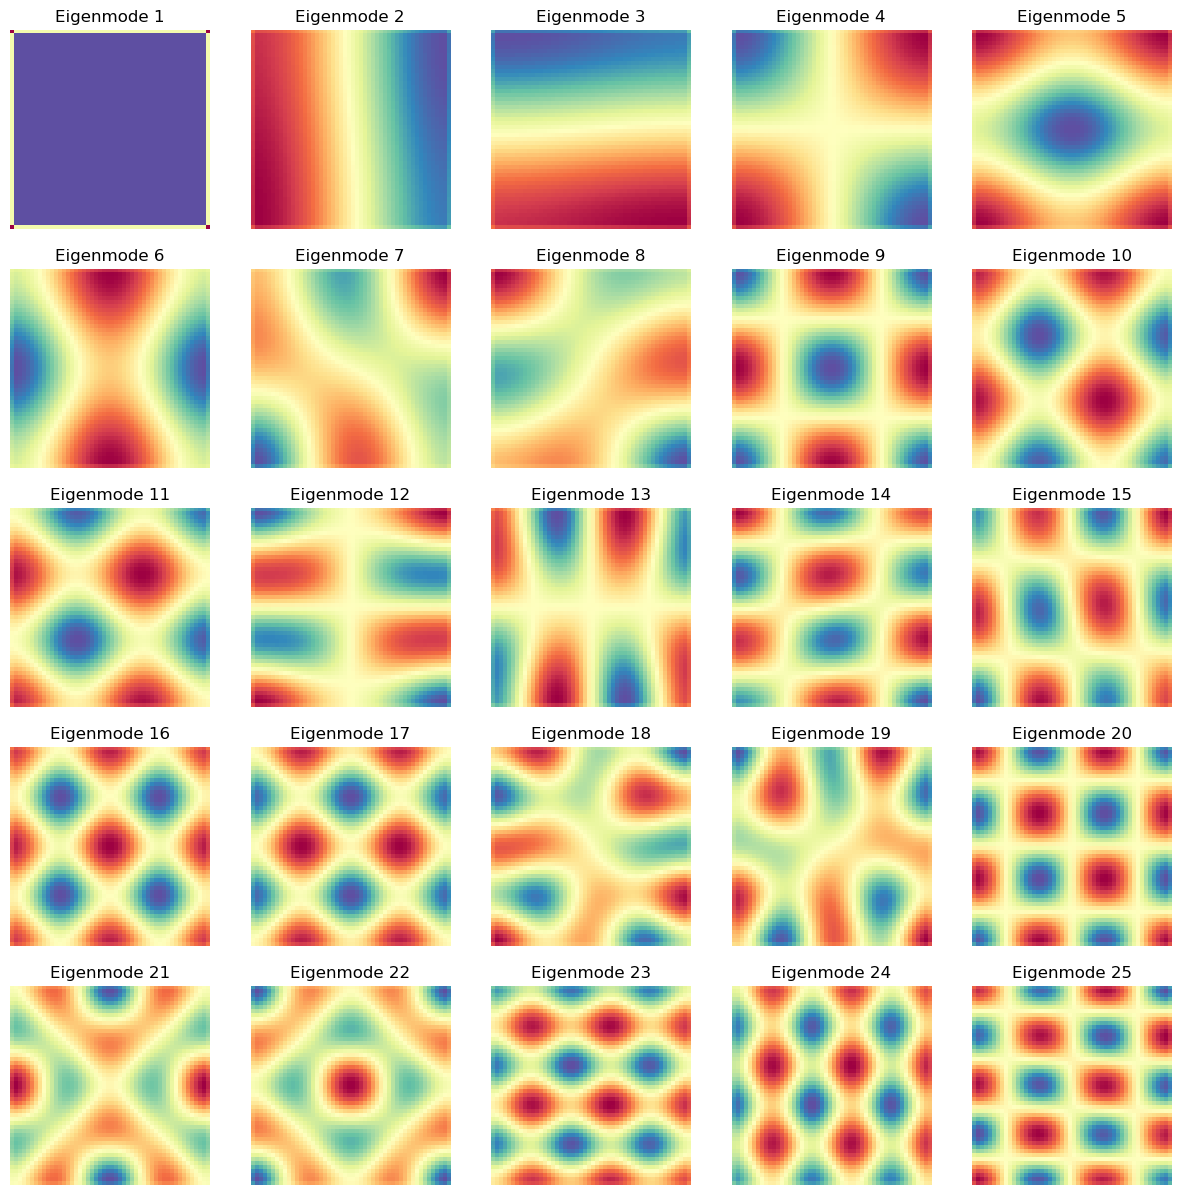

In [3]:
# Let's use gridspec to visualize the first few eigenmodes as images
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i in range(25):
    ax = axes[i // 5, i % 5]
    eigenmode = eigenmode_basis.eigenvectors[:, i].reshape(num_nodes, num_nodes)
    ax.imshow(eigenmode, cmap="Spectral")
    ax.set_title(f"Eigenmode {i + 1}")
    ax.axis("off")

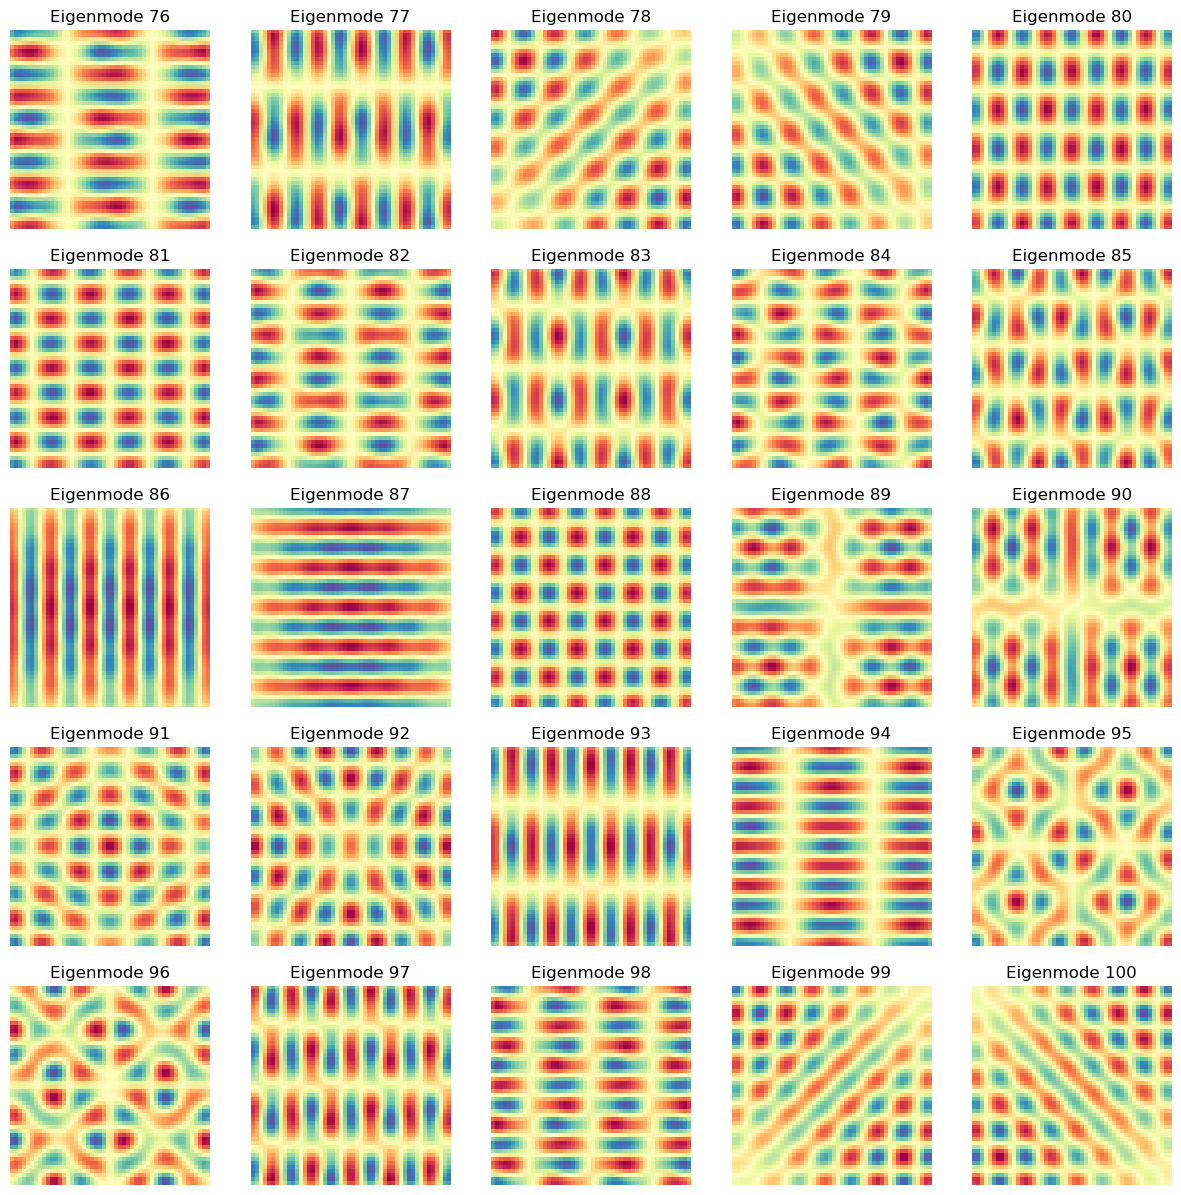

In [4]:
# Let's use gridspec to visualize the last few eigenmodes as images
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for i in range(25):
    ax = axes[i // 5, i % 5]
    eigenmode = eigenmode_basis.eigenvectors[:, -25 + i].reshape(num_nodes, num_nodes)
    ax.imshow(eigenmode, cmap="Spectral")
    ax.set_title(f"Eigenmode {eigenmode_basis.eigenvectors.shape[1] - 25 + i + 1}")
    ax.axis("off")

As we can see from the visualizations, the first few eigenmodes capture smooth, low-frequency patterns across the lattice, while the higher eigenmodes capture more complex, high-frequency patterns. This illustrates how eigenmode bases can provide a hierarchical representation of data defined over a graph structure.

## Encoding and Decoding with Eigenmode Bases

With the computed eigenmode basis, we can now encode and decode data defined over the graph. Encoding involves projecting the original high-dimensional data onto the eigenmode basis to obtain a lower-dimensional representation. Decoding involves reconstructing the original data from its lower-dimensional representation in the eigenmode basis.

Benefiting from the orthonormality of the eigenmode basis, the implemented functionality in SpectraNorm ([`gsp.EigenmodeBasis.encode`](/spectranorm/api/utils/gsp/#spectranorm.utils.gsp.EigenmodeBasis.encode) and [`gsp.EigenmodeBasis.decode`](/spectranorm/api/utils/gsp/#spectranorm.utils.gsp.EigenmodeBasis.decode)) allows us to easily perform these operations via optimized matrix multiplications.

As we used a lattice graph for this tutorial, let's try to encode and decode some exemplary images (as form of data that can be conveniently represented on a lattice graph) using the computed eigenmode basis. We will see how well we can reconstruct the original images using only a subset of the eigenmodes, demonstrating the power of eigenmode bases for dimensionality reduction and data representation.

For the sake of simplicity, let's utilize some black and white images that can be easily represented on our 50x50 lattice graph, e.g., digits from the MNIST dataset. We will encode these images into the eigenmode basis and then decode them back to the original space (with different numbers of eigenmodes), comparing the reconstructed images to the originals to assess the quality of the representation.

Fetching MNIST...


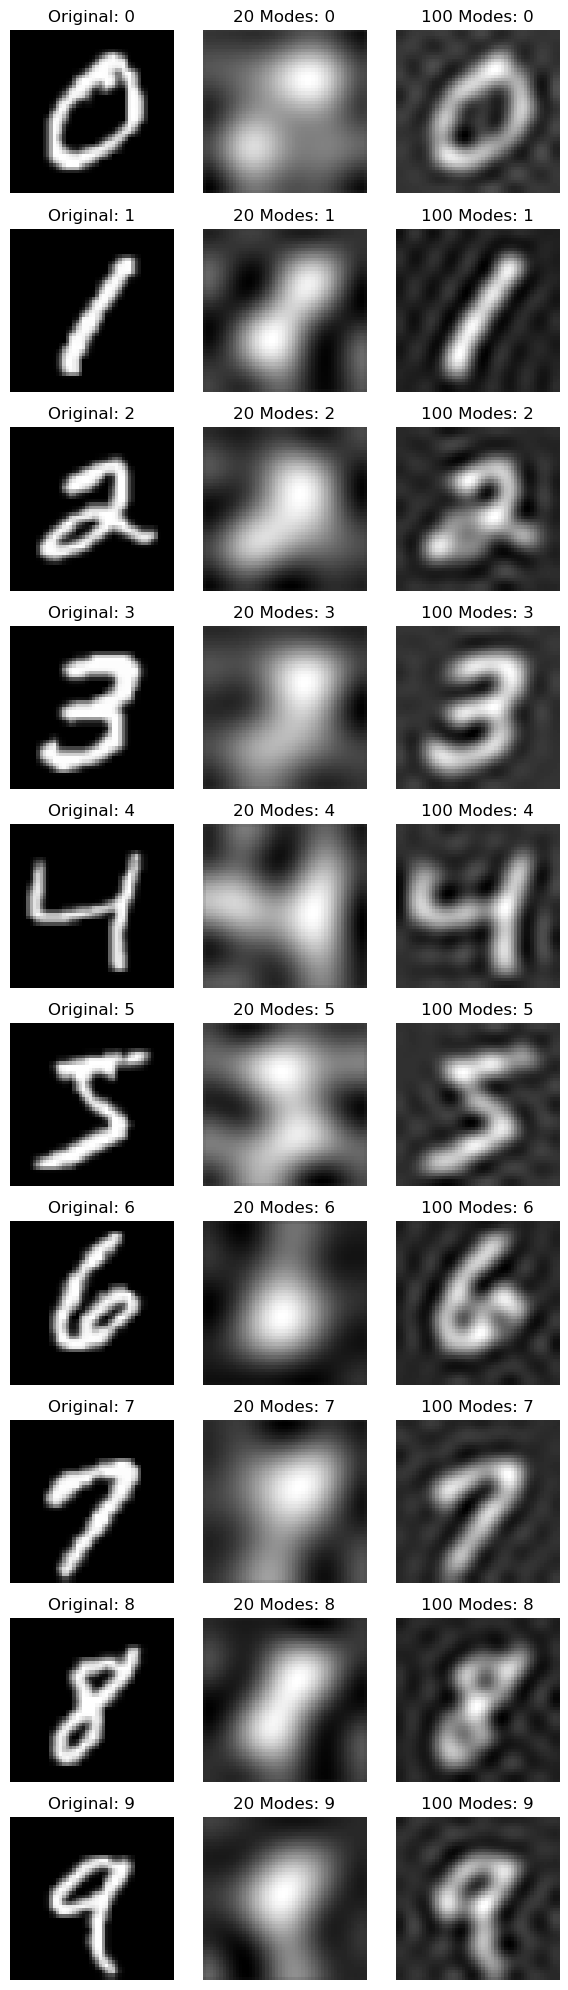

In [5]:
from skimage.transform import resize
from sklearn.datasets import fetch_openml

# 1. Load MNIST data (this may take a minute the first time)
print("Fetching MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target.astype(int)

# 2. Extract one sample of each digit (0-9)
digits = []
for i in range(10):
    # Find the first index where the label matches the digit
    idx = np.where(y == i)[0][0]
    # Reshape from flat 784 to 28x28
    img_28 = X[idx].reshape(28, 28)

    # 3. Resize to 50x50
    # anti_aliasing prevents jagged edges during upscaling
    img_50 = resize(img_28, (50, 50), anti_aliasing=True)

    digits.append(img_50)

# 3. For each digit, encode it using either 20 or 100 eigenmodes, then decode it back
# to the original space to visualize the results
digits_20 = []
digits_100 = []
for digit in digits:
    # Flatten the 50x50 image to a vector of length 2500
    digit_vector = digit.flatten()

    # Encode using the first 20 eigenmodes
    encoded_20 = eigenmode_basis.encode(digit_vector, n_modes=20)
    digits_20.append(eigenmode_basis.decode(encoded_20, n_modes=20).reshape(50, 50))

    # Encode using the first 100 eigenmodes
    encoded_100 = eigenmode_basis.encode(digit_vector, n_modes=100)
    digits_100.append(eigenmode_basis.decode(encoded_100, n_modes=100).reshape(50, 50))

# 4. Visualize the original and reconstructed digits
# We'll use a grid of 3 columns (original, 20 modes, 100 modes) and 10 rows (digits 0-9)
fig, axes = plt.subplots(10, 3, figsize=(6, 20))
for i in range(10):
    # Original digit
    axes[i, 0].imshow(digits[i], cmap="gray")
    axes[i, 0].set_title(f"Original: {i}")
    axes[i, 0].axis("off")

    # Reconstructed with 20 modes
    axes[i, 1].imshow(digits_20[i], cmap="gray")
    axes[i, 1].set_title(f"20 Modes: {i}")
    axes[i, 1].axis("off")

    # Reconstructed with 100 modes
    axes[i, 2].imshow(digits_100[i], cmap="gray")
    axes[i, 2].set_title(f"100 Modes: {i}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

As we can see from the visualizations, the first few eigenmodes can only capture the most basic, low-frequency features of the images, resulting in blurry reconstructions. As we include more eigenmodes in the encoding, we can capture more details and higher-frequency features, leading to sharper reconstructions that more closely resemble the original images. This illustrates how eigenmode bases can be used for efficient data representation and dimensionality reduction while preserving important structural information.

The example above demonstrates how keeping only 100 eigenmodes (out of 2500) can still capture a significant amount of information about the original images, to the extent that we can visually distinguish the digits, while drastically reducing the dimensionality of the data. This is a key advantage of using eigenmode bases for representing high-dimensional data defined over graphs.

## Saving and Loading Eigenmode Bases

The computed eigenmode basis can be saved to disk for later use, allowing us to reuse the same basis for encoding and decoding without having to recompute it each time. SpectraNorm provides functionality to save and load eigenmode bases using the [`gsp.EigenmodeBasis.save`](/spectranorm/api/utils/gsp/#spectranorm.utils.gsp.EigenmodeBasis.save) and [`gsp.EigenmodeBasis.load`](/spectranorm/api/utils/gsp/#spectranorm.utils.gsp.EigenmodeBasis.load) methods.

Below, we provide an example of how to save the computed eigenmode basis used in this tutorial. The next tutorial on Spectral Normative Modeling will load this saved eigenmode basis to perform normative modeling analyses on this hypothetical 2D lattice graph data.

In [7]:
eigenmode_basis.save("eigenmode_basis.joblib", overwrite=True)

## Concluding Remarks

This tutorial was meant as a brief introduction to concepts and applications of graph signal processing and eigenmode bases, using a simple lattice graph as an example. The simple graph spectral encoding and decoding operations, formulated as matrix multiplications, can help summarize high-dimensional data in a lower-dimensional latent space, while preserving important structural information.

Note that while this tutorial focused on a simple lattice graph, the same principles apply to more complex graph structures. For instance, in neuroimaging, nodes of a hypothetical graph encoding high-dimensional brain data could represent vertices on the cortical surface, voxels in the brain, or possibly fixels in the case of diffusion MRI data. The edges of the graph could represent geometric proximity, functional connectivity, or structural connectivity between these nodes. By computing eigenmode bases from such graphs, we can find concise representations of complex brain data that capture important patterns and relationships.

Without loss of generality, the same approach described above can be applied to any such graph structure, allowing us to reconstruct and analyze high-dimensional data in a lower-dimensional latent space using eigenmode bases.